In [2]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
# import src.statsmodels as statsmodels 
import copy


In [3]:
!ls binaural_unit_activations

word_task_conventional_layer_order
word_task_half_co_loc_v08_gender_bal_4M_sanity
word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout
word_task_v09_control_no_attn
word_task_v09_cue_loc_task


In [4]:
model = "word_task_conventional_layer_order"

analysis_dir = Path(f"binaural_unit_activations/{model}")

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
print(h5.keys())
for key in h5.keys():
    print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

<KeysViewHDF5 ['attn0_target', 'attn1_gains', 'attn1_target', 'attn2_gains', 'attn2_target', 'attn3_gains', 'attn3_target', 'attn4_gains', 'attn4_target', 'attn5_gains', 'attn5_target', 'attn6_gains', 'attn6_target', 'attncoch_gains', 'attnfc_gains', 'attnfc_target', 'cochleagram_cue', 'cochleagram_fg', 'conv_block_0_ln_cue', 'conv_block_0_ln_target', 'conv_block_0_relu_cue', 'conv_block_0_relu_target', 'conv_block_1_ln_cue', 'conv_block_1_ln_target', 'conv_block_1_relu_cue', 'conv_block_1_relu_target', 'conv_block_2_ln_cue', 'conv_block_2_ln_target', 'conv_block_2_relu_cue', 'conv_block_2_relu_target', 'conv_block_3_ln_cue', 'conv_block_3_ln_target', 'conv_block_3_relu_cue', 'conv_block_3_relu_target', 'conv_block_4_ln_cue', 'conv_block_4_ln_target', 'conv_block_4_relu_cue', 'conv_block_4_relu_target', 'conv_block_5_ln_cue', 'conv_block_5_ln_target', 'conv_block_5_relu_cue', 'conv_block_5_relu_target', 'conv_block_6_ln_cue', 'conv_block_6_ln_target', 'conv_block_6_relu_cue', 'conv_blo

In [5]:
### Get layer shape dict 

layer_shape_dict = pickle.load(open(analysis_dir / f"{model}_layer_shape_dict_time_avg.pkl", "rb"))
# batch got saved, drop batch dim in layer_shape_dict
layer_shape_dict = {k: v[1:] for k,v in layer_shape_dict.items() if 'gains' not in k}

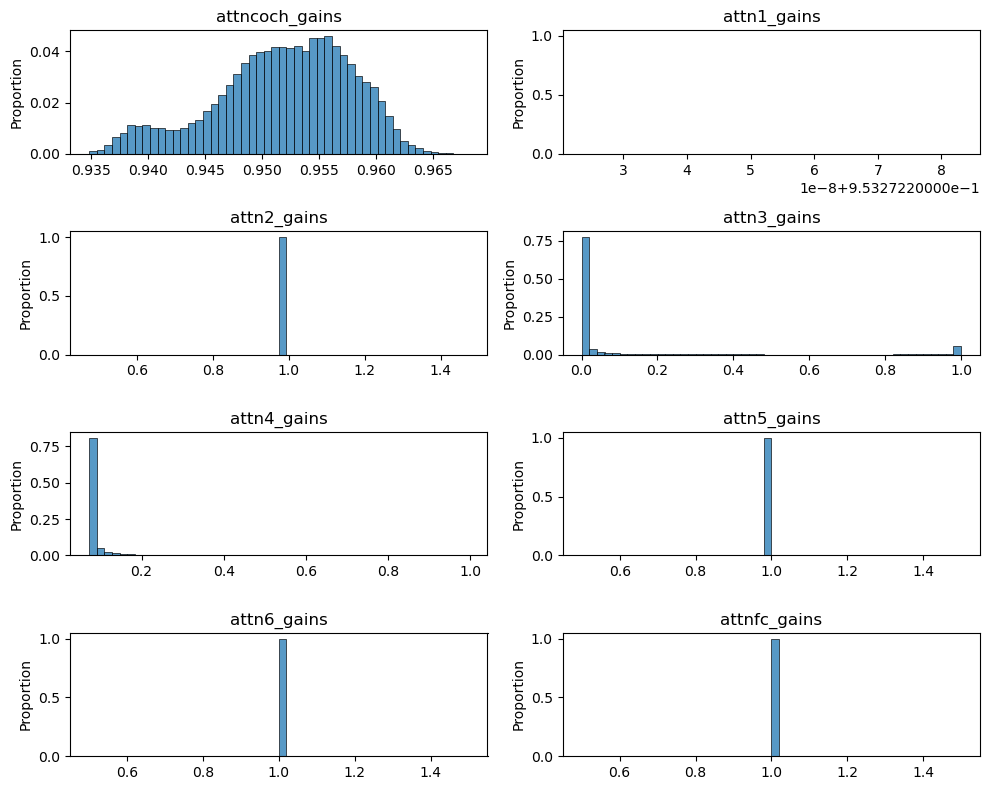

In [7]:
## Plot distribution of gains 
# gain_keys = [key for key in h5.keys() if "gain" in key]
gain_keys = ['attncoch_gains',
'attn1_gains',
 'attn2_gains',
 'attn3_gains',
 'attn4_gains',
 'attn5_gains',
 'attn6_gains',
 'attnfc_gains']

# get number of subplots for gains 
n_gains = len(gain_keys)
n_rows = int(np.ceil(n_gains/2))
n_cols = 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 8))
axs = axs.flatten()
for ix, key in enumerate(gain_keys):
    sns.histplot(data=h5[key][:].flatten(), bins=50, stat='proportion', ax=axs[ix])
    axs[ix].set_title(key)

plt.tight_layout()


### For spatial tuning analysis, average over examples presented at same location, and compare across locations. 



Optimal number of bins: 9


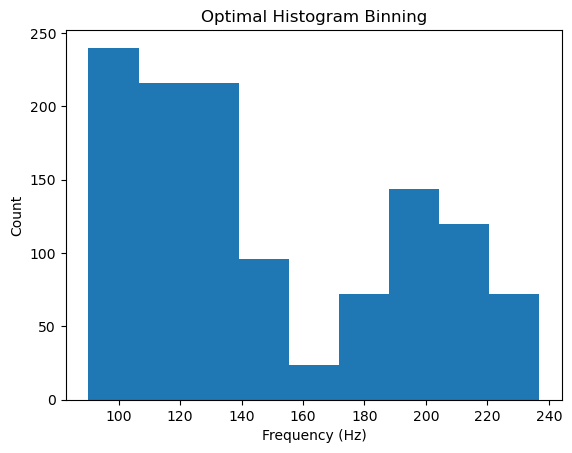

In [8]:
### get binning for pitch classes 

import numpy as np
import matplotlib.pyplot as plt

def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

# Example usage with target_f0s data
# target_f0s = np.random.rand(100) * 100  # Replace with your actual data
optimal_bins = optimal_bin_count(target_f0s)
print(f"Optimal number of bins: {optimal_bins}")

# Plot the histogram with the optimal number of bins
plt.hist(target_f0s, bins=optimal_bins)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('Optimal Histogram Binning')
plt.show()

In [9]:
optimal_bins

9

9 10


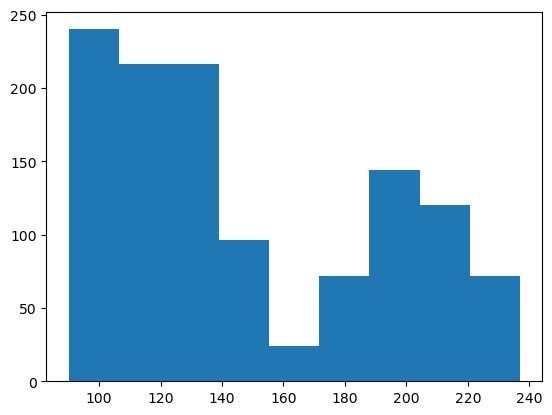

In [10]:
## Get spatial selectivity for each layer
## Get ixs corresponding to locations
#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
location_ixs = {}
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        location_ixs['front'] = loc_ixs
    elif elev == 0:
        location_ixs[f"{azim} azim"] = loc_ixs
    elif azim == 0:
        location_ixs[f"{elev} elev"] = loc_ixs


# get pitch labeling  
## Need to bin f0 into categories
# find number of bins that has roughly equal number of examples per bin 

outs = plt.hist(target_f0s, bins=optimal_bins)
counts, bins = outs[0], outs[1]
print(len(counts), len(bins))
f0_assignments = np.digitize(target_f0s, bins, right=True)
bins = bins.round(0)
f0_bins = bins[f0_assignments]
f0_bins = f0_bins.astype(int)

# group like with locations 
f0_ixs = {}
for f0 in np.unique(f0_bins):
    f0_ixs[f"{f0} Hz"] = np.where(f0_bins == f0)[0]

class_assignments = {**location_ixs, **f0_ixs}

In [11]:
# layer to fit pca on is cue 

layer_name = 'hann_pool_1_cue'

layer_act = h5[layer_name][:]


In [12]:
# all_activity = np.hstack([layer_act, attn_act])
all_activity = layer_act - layer_act.mean(1, keepdims=True)

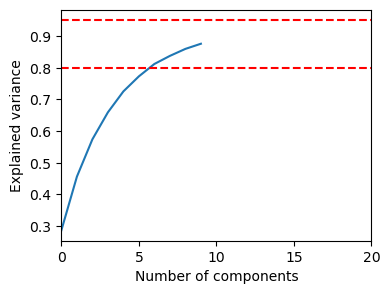

In [13]:
#### Run PCA on layer and see component loading
import sklearn 
from sklearn.decomposition import PCA


n_components=10 
pca = PCA(n_components=n_components, random_state=0, copy=True)
pca_acts = pca.fit_transform(all_activity)


plt.figure(figsize=(4, 3))
plt.plot(pca.explained_variance_ratio_.cumsum())
# add lines for 80% and 95% explained variance
plt.axhline(0.8, color='r', linestyle='--')
plt.axhline(0.95, color='r', linestyle='--')
plt.xlim(0, 20)
plt.ylabel("Explained variance")
plt.xlabel("Number of components")
plt.show()

# plot pca for each model layer 

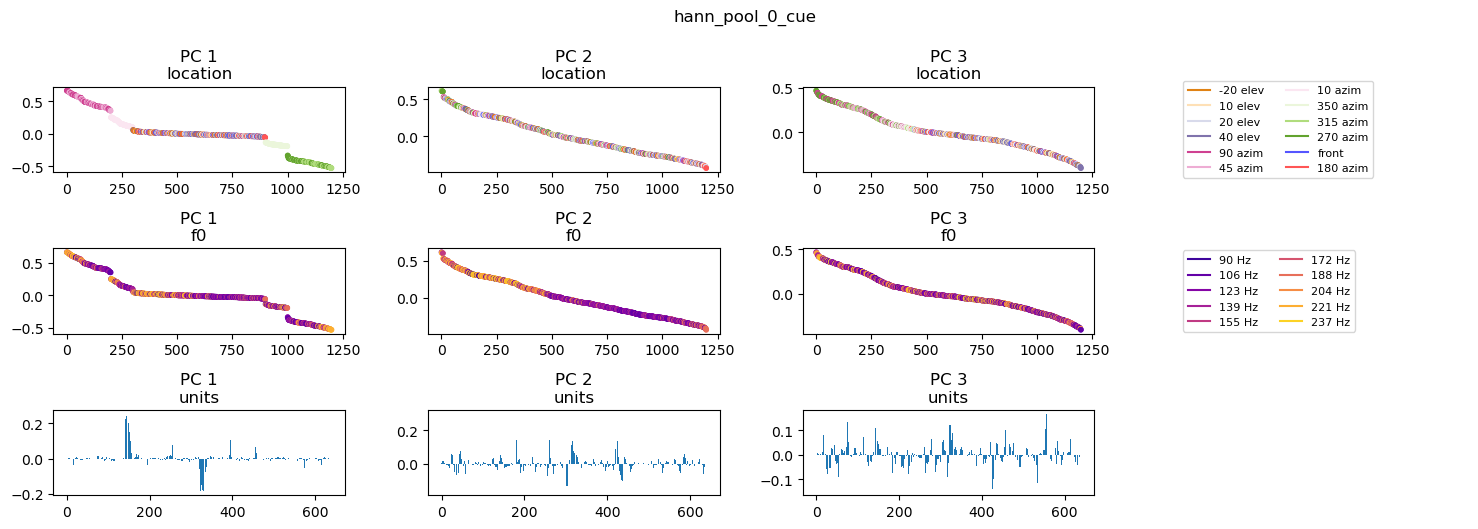

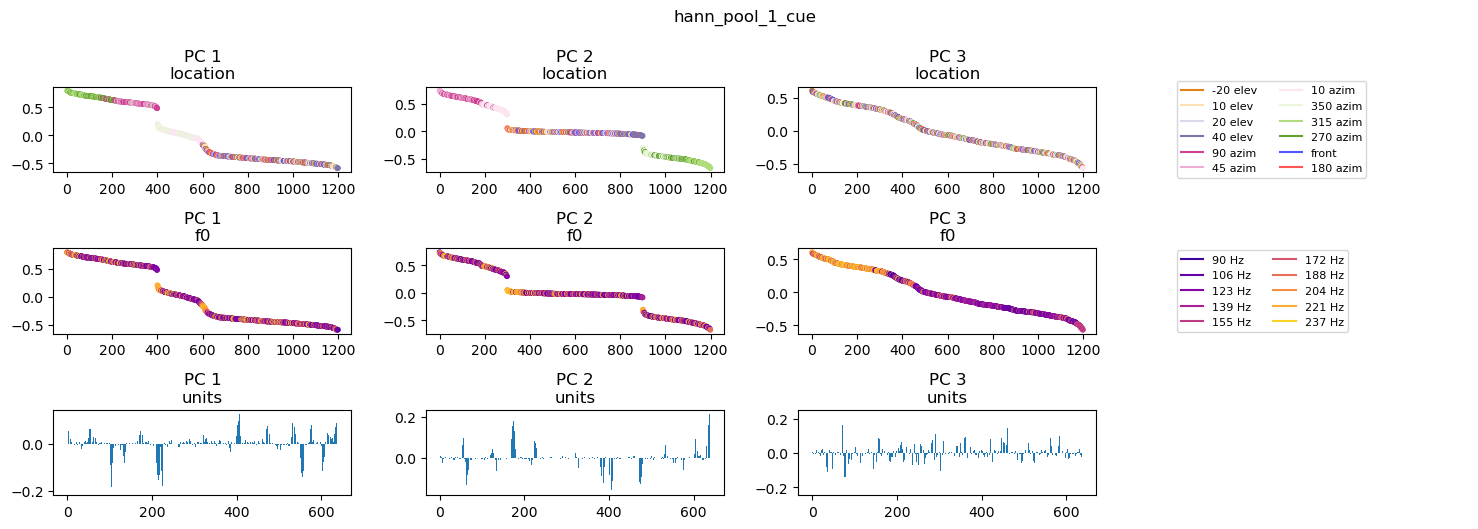

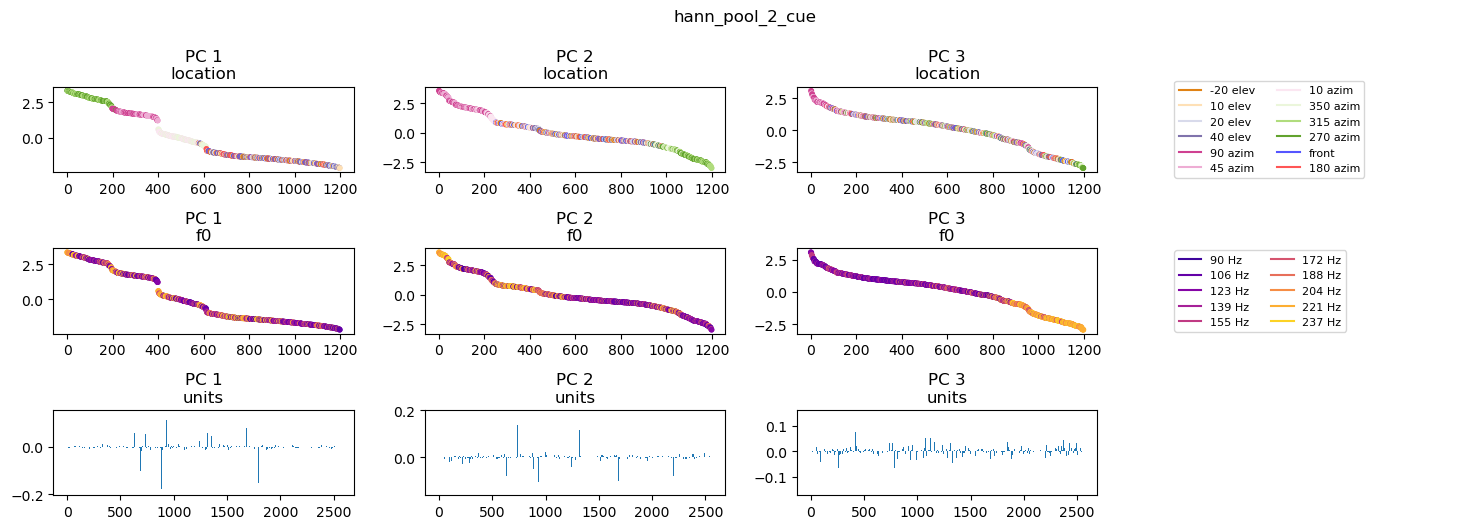

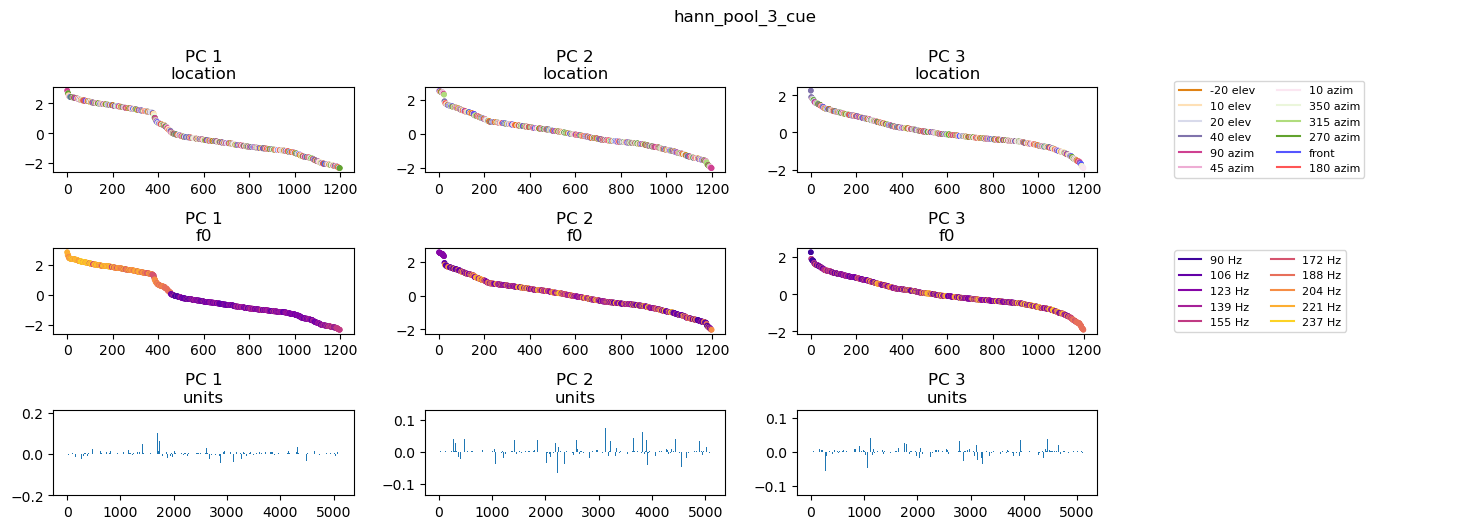

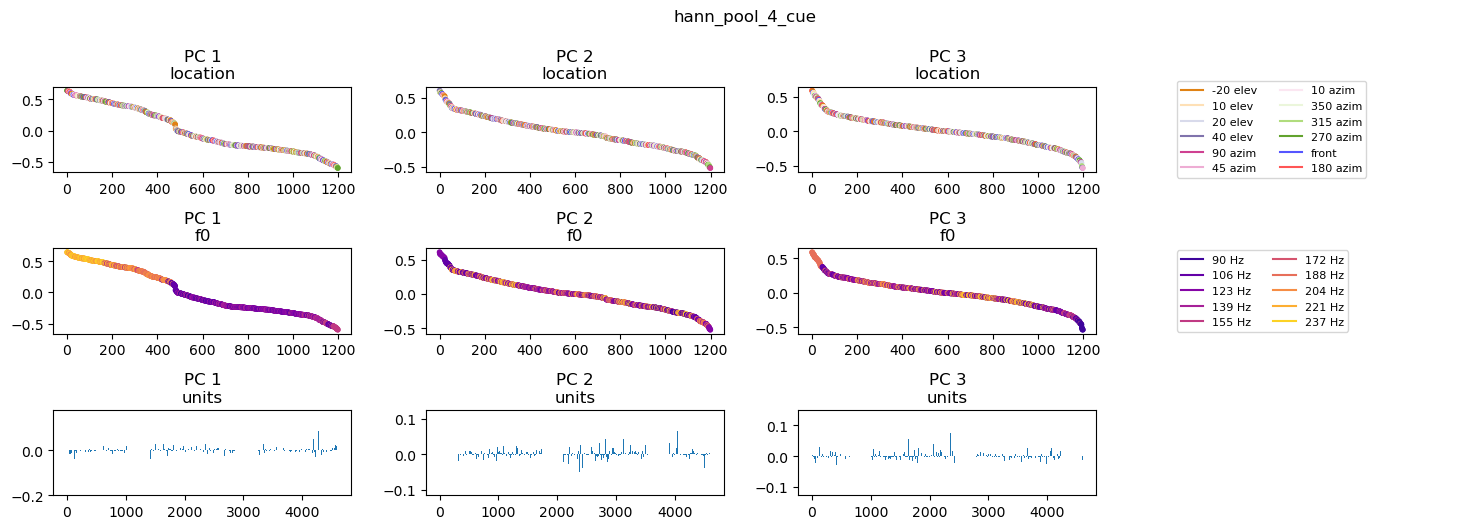

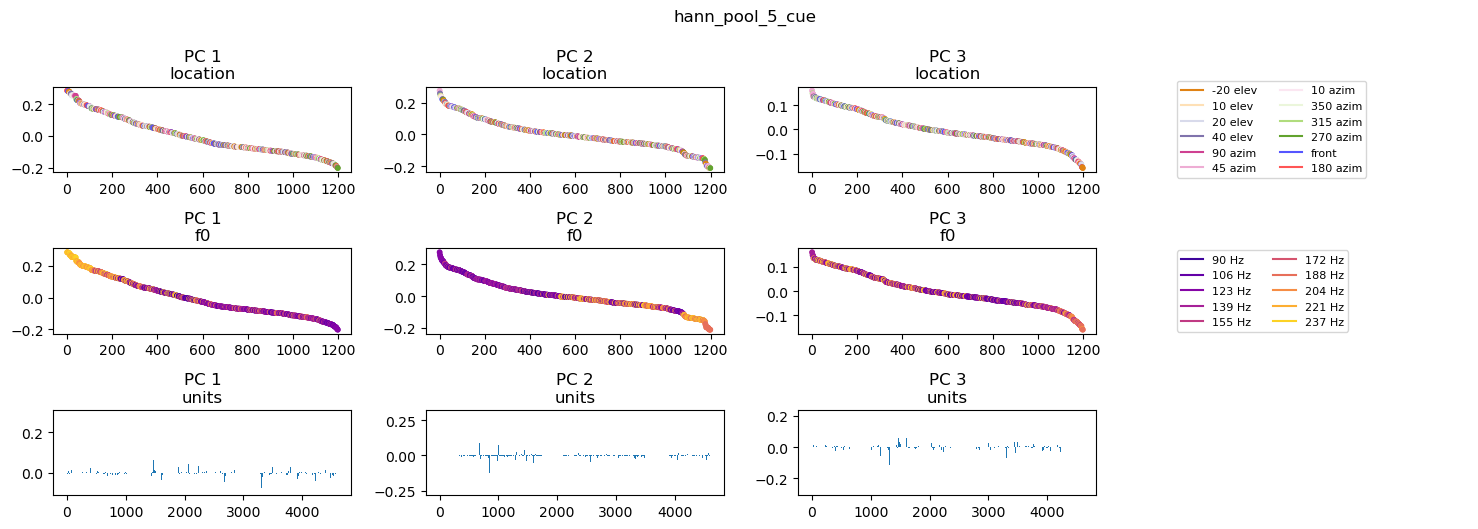

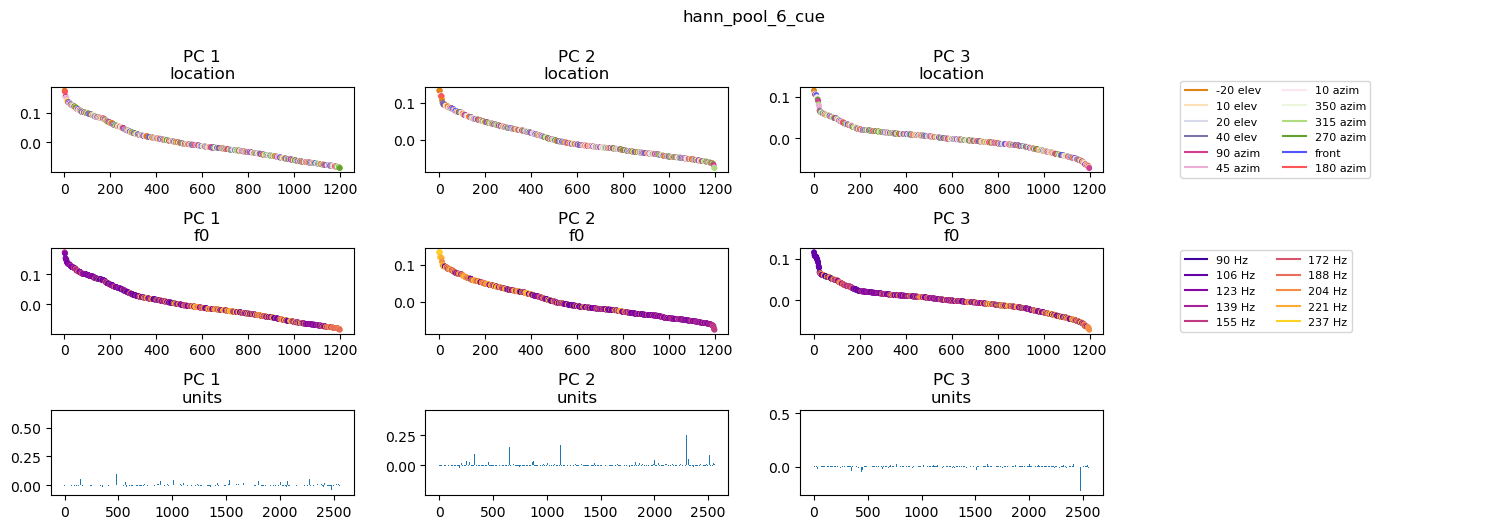

In [14]:

for layer_ix in np.arange(7):
    layer_name = f'hann_pool_{layer_ix}_cue'

    layer_act = h5[layer_name][:]
    all_activity = layer_act - layer_act.mean(1, keepdims=True)
    
    pca = PCA(n_components=n_components, random_state=0, copy=True)
    pca_acts = pca.fit_transform(all_activity)

    n_components_to_plot = 3
    n_pannels = n_components_to_plot + 1 

    fig, axs = plt.subplots(3,n_pannels, figsize=(15, 5))
    # axs=axs.flatten()
    axs = axs.T
    x=np.arange(0, pca_acts.shape[0])
    x_units = np.arange(pca.components_.shape[1])
    # get colormap based on keys feature keys 
    categories = class_assignments.keys()
    n_color_buffer = 0 

    # get colormap for elevations 
    elevs = [key for key in location_ixs.keys() if 'elev' in key]
    elev_cmap = sns.color_palette("PuOr", n_colors=len(elevs)+n_color_buffer)
    elev_palette = {k: elev_cmap[ix] for ix, k in enumerate(elevs)}

    azims = [key for key in location_ixs.keys() if 'azim' in key]
    azim_order  = ['90 azim', '45 azim', '10 azim', '350 azim',  '315 azim', '270 azim']

    azim_cmap = sns.color_palette("PiYG", n_colors=len(azim_order)+n_color_buffer)
    azim_palette = {k: azim_cmap[ix] for ix, k in enumerate(azim_order)}

    # front back palette 
    fb_palette = {k: sns.color_palette('seismic', n_colors=2)[ix] for ix, k in enumerate(['front', '180 azim'])}
    loc_palette = {**elev_palette, **azim_palette, **fb_palette}

    # get colormap for f0 
    cmap = sns.color_palette("plasma", n_colors=len(f0_ixs.keys())+n_color_buffer)
    f0_palette = {k: cmap[ix] for ix, k in enumerate(f0_ixs.keys())}

    palette = { **f0_palette, **loc_palette}
    # assign color for each bar based on feature

    loc_colors = np.zeros((pca_acts.shape[0], 3))
    f0_colors = np.zeros((pca_acts.shape[0], 3))
    for key, vals in location_ixs.items():
        loc_colors[vals, :] = palette[key]

    for key, vals in f0_ixs.items():
        # print(vals)
        f0_colors[vals, :] = palette[key]

    for i in range(n_components_to_plot):
        pc_sounds  = pca_acts[:,i]
        order = np.argsort(pc_sounds)[::-1]

        pc_to_plot = pc_sounds[order]
        # axs[i, 0].bar(x, pc_to_plot, color=loc_colors[order], align='center')
        axs[i, 0].scatter(x, pc_to_plot, color=loc_colors[order], marker='.')
        axs[i, 0].set_title(f"PC {i+1}\nlocation")

        # axs[i, 1].fill_between(x, np.zeros_like(x), pca_acts[:,i], color=f0_colors)
        # axs[i, 1].bar(x, pc_to_plot, color=f0_colors[order], align='center')
        axs[i, 1].scatter(x, pc_to_plot, color=f0_colors[order], marker='.')
        axs[i, 1].set_title(f"PC {i+1}\nf0")
        # add f0 labels as legend

        axs[i, 2].bar(x_units, pca.components_[i], align='center')
        axs[i, 2].set_title(f"PC {i+1}\nunits")

    plt.tight_layout()  

    for key, color in loc_palette.items():
        axs[n_pannels - 1, 0].plot(0, 0, color=color, label=key)
    axs[n_pannels - 1,0].legend(loc='center left', ncol=2,  fontsize=8)

    for key, color in f0_palette.items():
        axs[n_pannels - 1, 1].plot(0, 0, color=color, label=key)
    axs[n_pannels - 1,1].legend(loc='center left', ncol=2, fontsize=8)


    for ax in axs[n_pannels-1]:
        ax.axis('off')
    plt.suptitle(f"{layer_name}", y=1.05)

### measure how gains change features 

Identify units based on gains, color in PC plot

In [39]:
from mpl_toolkits.mplot3d import Axes3D


In [161]:


## layer 3 is first with bimodal gains 
layer_ix = 5
layer_name = f'hann_pool_{layer_ix}_cue'
target_pre_gain_name = f'hann_pool_{layer_ix}_target'
target_post_gain_name = f"attn{layer_ix+1}_target"
gain_name =  f'attn{layer_ix+1}_gains'

acts_for_pca = h5[layer_name][:]
all_activity = acts_for_pca - acts_for_pca.mean(1, keepdims=True)

pca = PCA(n_components=n_components, random_state=0, copy=True)
pca_acts = pca.fit_transform(all_activity)

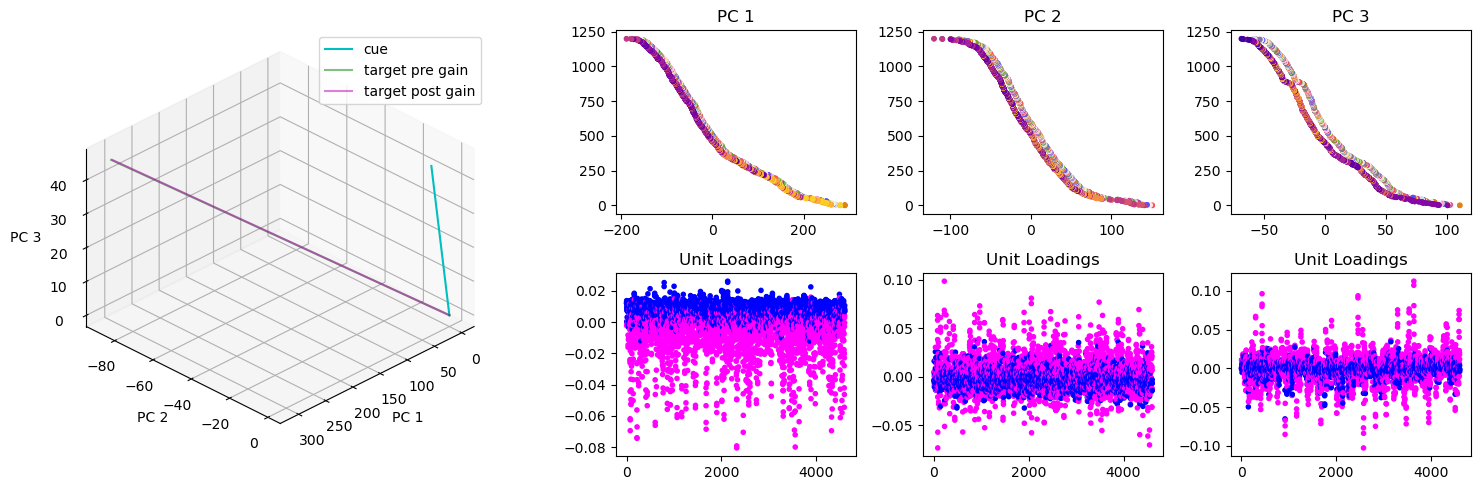

In [170]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA


example_ix = 23

cue_act = h5[layer_name][example_ix]
target_pre_gain = h5[target_pre_gain_name][example_ix]
target_post_gain = h5[target_post_gain_name][example_ix]
gain_act = h5[gain_name][example_ix]

selected_ixs = gain_act >= 0.9 

# make unit color map
unit_colors = np.zeros((cue_act.shape[0], 3))
# set default to blue 
unit_colors[:, 2] = 1
# set selected to red 
unit_colors[selected_ixs, 0] = 1


cue_pcs = pca.transform(cue_act.reshape(1, -1))
target_pre_gain_pcs = pca.transform(target_pre_gain.reshape(1, -1))
target_post_gain_pcs = pca.transform(target_post_gain.reshape(1, -1))

shared_x = np.arange(0, pca_acts.shape[0])

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 5)

# 3D plot spanning the first two columns and both rows
# change origin of 3d plot 

ax3d = fig.add_subplot(gs[:, :2], projection='3d', proj_type = 'ortho')
ax3d.plot([0, cue_pcs[0, 0]], [0, cue_pcs[0, 1]], [0, cue_pcs[0, 2]], color='c', label='cue')
ax3d.plot([0, target_pre_gain_pcs[0, 0]], [0, target_pre_gain_pcs[0, 1]], [0, target_pre_gain_pcs[0, 2]], color='g', label='target pre gain', alpha=0.5)
ax3d.plot([0, target_post_gain_pcs[0, 0]], [0, target_post_gain_pcs[0, 1]], [0, target_post_gain_pcs[0, 2]], color='m', label='target post gain', alpha=0.5)
ax3d.legend()
# label the axes
ax3d.set_xlabel('PC 1')
ax3d.set_ylabel('PC 2')
ax3d.set_zlabel('PC 3')
ax3d.view_init(30, 45)



# 2D plots for the remaining columns
for ix in range(2,5):
    pc_sounds  = pca_acts[:,ix-2]
    order = np.argsort(pc_sounds)[::-1]
    pc_to_plot = pc_sounds[order]

    ax2d_1 = fig.add_subplot(gs[0, ix])
    ax2d_1.scatter(pc_to_plot + 5, shared_x, color=loc_colors[order], marker='.')
    ax2d_1.scatter(pc_to_plot - 5, shared_x, color=f0_colors[order], marker='.')

    ax2d_1.set_title(f'PC {ix-1}')

    ax2d_2 = fig.add_subplot(gs[1, ix])
    ax2d_2.scatter(np.arange(pca.components_.shape[1]), pca.components_[ix-2], color=unit_colors, marker='.')
    ax2d_2.set_title('Unit Loadings')


plt.tight_layout()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


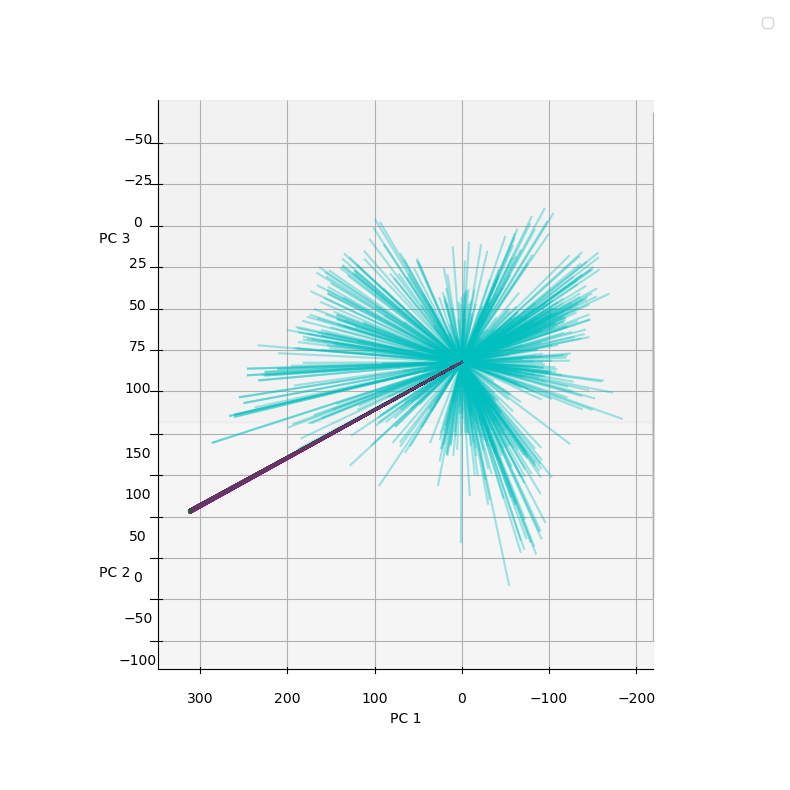

In [169]:
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(1, 1)
ax3d = fig.add_subplot(gs[:, :2], projection='3d', proj_type = 'ortho')

n_examples = 1200


cue_act = h5[layer_name][:]
target_pre_gain = h5[target_pre_gain_name][:]
target_post_gain = h5[target_post_gain_name][:]
gain_act = h5[gain_name][:]



cue_pcs = pca.transform(cue_act)
target_pre_gain_pcs = pca.transform(target_pre_gain)
target_post_gain_pcs = pca.transform(target_post_gain)


# Create the figure and GridSpec


# 3D plot spanning the first two columns and both rows
# change origin of 3d plot 
for example_ix in range(n_examples):
    ax3d.plot([0, cue_pcs[example_ix, 0]], [0, cue_pcs[example_ix, 1]], [0, cue_pcs[example_ix, 2]], color='c', alpha=0.2)
    ax3d.plot([0, target_pre_gain_pcs[example_ix, 0]], [0, target_pre_gain_pcs[example_ix, 1]], [0, target_pre_gain_pcs[example_ix, 2]], color='g', alpha=0.2)
    ax3d.plot([0, target_post_gain_pcs[example_ix, 0]], [0, target_post_gain_pcs[example_ix, 1]], [0, target_post_gain_pcs[example_ix, 2]], color='m', alpha=0.2)

# ax3d.plot([0, cue_pcs[0, 0]], [0, cue_pcs[0, 1]], [0, cue_pcs[0, 2]], color='c', label='cue' if example_ix == 0 else None, alpha=0.2)
# ax3d.plot([0, target_pre_gain_pcs[0, 0]], [0, target_pre_gain_pcs[0, 1]], [0, target_pre_gain_pcs[0, 2]], color='g', label='target pre gain' if example_ix == 0 else None, alpha=0.2)
# ax3d.plot([0, target_post_gain_pcs[0, 0]], [0, target_post_gain_pcs[0, 1]], [0, target_post_gain_pcs[0, 2]], color='m', label='target post gain' if example_ix == 0 else None, alpha=0.2)

# plot all examples 
ax3d.legend()
# label the axes
ax3d.set_xlabel('PC 1')
ax3d.set_ylabel('PC 2')
ax3d.set_zlabel('PC 3')
ax3d.view_init(330, 270)

## Look at change in angles between cue, target and target post gain 


In [126]:

n_examples = h5[layer_name].shape[0]
cue_target_sims = np.zeros(n_examples)
cue_post_target_sims = np.zeros(n_examples)

cue_target_sims_pc_space = np.zeros((n_examples))
cue_post_target_sims_pc_space = np.zeros((n_examples))


for example_ix in range(n_examples):
    cue_act = h5[layer_name][example_ix]
    target_pre_gain = h5[target_pre_gain_name][example_ix]
    target_post_gain = h5[target_post_gain_name][example_ix]
    gain_act = h5[gain_name][example_ix]

    cue_target_sims[example_ix] = np.dot(target_post_gain, target_pre_gain) / (np.linalg.norm(target_post_gain) * np.linalg.norm(target_pre_gain))
    cue_post_target_sims[example_ix] = np.dot(cue_act, target_post_gain) / (np.linalg.norm(cue_act) * np.linalg.norm(target_post_gain))

    # transform and recompute 
    cue_pcs = pca.transform(cue_act.reshape(1, -1))
    target_pre_gain_pcs = pca.transform(target_pre_gain.reshape(1, -1))
    target_post_gain_pcs = pca.transform(target_post_gain.reshape(1, -1))

    # get sims 
    cue_target_sims_pc_space[example_ix] = np.dot(target_post_gain_pcs, target_pre_gain_pcs.T) / (np.linalg.norm(target_post_gain_pcs) * np.linalg.norm(target_pre_gain_pcs))
    cue_post_target_sims_pc_space[example_ix] = np.dot(cue_pcs, target_post_gain_pcs.T) / (np.linalg.norm(cue_pcs) * np.linalg.norm(target_post_gain_pcs)) 


/tmp/ipykernel_973838/2525987713.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cue_target_sims_pc_space[example_ix] = np.dot(target_post_gain_pcs, target_pre_gain_pcs.T) / (np.linalg.norm(target_post_gain_pcs) * np.linalg.norm(target_pre_gain_pcs))
/tmp/ipykernel_973838/2525987713.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cue_post_target_sims_pc_space[example_ix] = np.dot(cue_pcs, target_post_gain_pcs.T) / (np.linalg.norm(cue_pcs) * np.linalg.norm(target_post_gain_pcs))
/tmp/ipykernel_973838/2525987713.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ens

(0.0, 1.0)

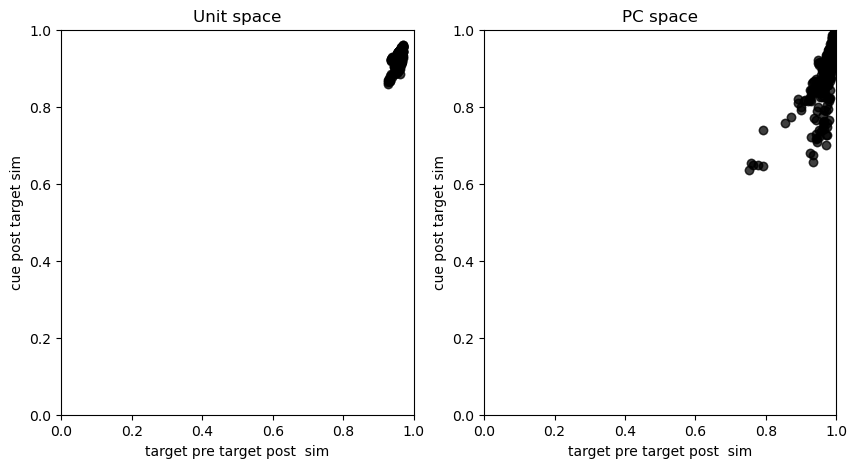

In [129]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
max_lim = max(cue_target_sims.max(), cue_post_target_sims.max())
axs[0].scatter(cue_target_sims, cue_post_target_sims, c='k', alpha=0.5)
axs[0].set_xlabel('target pre target post  sim')
axs[0].set_ylabel('cue post target sim')
axs[0].set_title('Unit space')
axs[0].set_xlim([0, 1])
axs[0].set_ylim([0, 1])

pc_max_lim = max(cue_target_sims_pc_space.max(), cue_post_target_sims_pc_space.max())
axs[1].scatter(cue_target_sims_pc_space, cue_post_target_sims_pc_space, c='k', alpha=0.5)
axs[1].set_xlabel('target pre target post  sim')
axs[1].set_ylabel('cue post target sim')
axs[1].set_title('PC space')
axs[1].set_xlim([0, 1])
axs[1].set_ylim([0, 1])
